# BESS Layout Optimization Tool

This notebook implements a layout optimization engine for Battery Energy Storage Systems (BESS).

## Objectives

- Define an arbitrary site using a polygon
- Place different types of equipment:
  - BESS containers (20 ft)
  - MVS / PCS containers (20 ft)
- Define:
  - Equipment footprint (2D)
  - Clearance distances (overlapping allowed)
- Configure maximum number of BESS per MVS
- Optimize layout to maximize battery count under constraints

## Key Assumptions

- Rectangular equipment footprints
- Clearance zones are allowed to overlap
- Equipment footprints cannot overlap
- Each BESS must be assigned to a MVS

In [24]:
# Install required packages (run once)

!pip install shapely matplotlib numpy

# Environment Check

This section ensures that all required libraries are correctly installed.

If this cell runs successfully, the environment is ready to execute the layout optimization workflow.

In [25]:
# Quick sanity check

from shapely.geometry import Polygon

poly = Polygon([(0, 0), (10, 0), (10, 10), (0, 10)])

print("✅ Shapely working correctly:", poly.area == 100)

✅ Shapely working correctly: True


# Configuration

In this section, the main parameters of the layout problem are defined.

## Site Definition
- The site is defined as a polygon using a list of vertices (X, Y)

## Zone Types

Two types of zones are defined:

### 1. Non-buildable areas
- Equipment cannot be placed
- Can still be used for:
  - cable routing
  - access paths
  - fire lanes
- These areas block placement but do not reduce total usable layout space

### 2. Restricted areas
- Completely excluded from the site
- No usage allowed
- These areas are subtracted from the site geometry

## Equipment Types
- BESS containers
- MVS / PCS containers

Each equipment type includes:
- Footprint (width and height)
- Clearance (allowed to overlap with other clearance zones)

## System Constraints
- Maximum number of BESS units per MVS
- Grid resolution for placement candidates

This structure allows modeling realistic BESS layouts with engineering constraints.

In [33]:

blue_zone = [
    (15.4, 0),
    (21.9, 0),
    (21.9, 90.4),
    (15.4, 90.4)
]

blue_diagonal = [
    (21.9, 0),
    (35, 0),
    (28, -10),
    (15.4, 0)
]

orange_zone_left = [
    (0, 0),
    (8, 0),
    (12, 85),
    (0, 90)
]



In [34]:
# =========================================================
# CONFIGURATION
# =========================================================

CONFIG = {

    # ---------------------------
    # SITE DEFINITION (polygon)
    # ---------------------------
    "site_vertices": [
        (0, 0),
        (53.3, 0),
        (53.3, 90.4),
        (21.4, 90.4),
        (10, 10),
        (0, 20)
    ],

    # setback from boundary
    "setback": 0,

    # ---------------------------
    # ZONES
    # ---------------------------
    
    
    "zones": {

        # Cannot place equipment, but usable space
        "non_buildable": [
            blue_zone,
            blue_diagonal,
            orange_zone_left
        ],

        # Completely excluded
        "restricted": [
            # Example:
            # [(80,10), (100,10), (100,30), (80,30)]
        ]
    },

    # ---------------------------
    # EQUIPMENT TYPES
    # ---------------------------
    "equipment": {

        "BESS": {
            "width": 6.06,
            "height": 2.44,
            "clearance": 2.0
        },

        "MVS": {
            "width": 6.06,
            "height": 2.44,
            "clearance": 3.0
        }
    },

    # ---------------------------
    # SYSTEM CONSTRAINTS
    # ---------------------------
    "max_bess_per_mvs": 4,

    # grid resolution (controls density of search)
    "grid_resolution": 2.5
}

# Geometry and Site Preparation

This section defines how the site geometry is prepared before placing equipment.

## Key Steps

1. Create the base site polygon from vertices
2. Apply setback (inward buffer)
3. Subtract restricted areas from the site
4. Keep non-buildable zones as internal constraints
5. Generate candidate placement positions using a grid

## Important Behavior

- Restricted areas → removed from the usable site
- Non-buildable areas → remain inside the site but block placement
- Clearance between equipment is allowed to overlap

The combination of these rules allows realistic modeling of:
- access roads
- fire lanes
- no-build zones
- environmental restrictions

In [27]:
from shapely.geometry import Polygon
import numpy as np

def create_site(vertices):
    site = Polygon(vertices)

    if not site.is_valid:
        raise ValueError("Invalid polygon: check vertex order")

    return site


def prepare_site(site, config):

    # 1. Apply setback
    usable_site = site.buffer(-config["setback"])

    # 2. Remove restricted zones
    for zone in config["zones"]["restricted"]:
        zone_poly = Polygon(zone)
        usable_site = usable_site.difference(zone_poly)

    # 3. Keep non-buildable zones (for placement checks later)
    non_buildable_polys = [
        Polygon(z) for z in config["zones"]["non_buildable"]
    ]

    return usable_site, non_buildable_polys


def create_candidate_grid(site, resolution):
    minx, miny, maxx, maxy = site.bounds

    xs = np.arange(minx, maxx, resolution)
    ys = np.arange(miny, maxy, resolution)

    return [(x, y) for x in xs for y in ys]

# Equipment Placement Logic

This section defines how equipment is placed within the site.

## Placement Rules

### 1. Footprint constraints
- Equipment footprints must:
  - Be fully inside the usable site
  - Not intersect with other equipment
  - Not overlap with non-buildable zones

### 2. Clearance concept
- Each equipment has a clearance distance
- Clearance areas:
  - Can overlap with other clearances
  - Represent safety, fire, or O&M spacing
- Clearance is NOT treated as a hard exclusion

### 3. Placement Strategy

The placement is done sequentially:

1. Place MVS units first
2. Assign BESS units to MVS based on proximity
3. Ensure each MVS does not exceed maximum BESS capacity

## Objective

Maximize the number of BESS units while ensuring:
- Proper assignment to MVS
- Valid spatial layout


In [28]:
from shapely.geometry import box

def create_equipment_polygon(x, y, width, height):
    return box(x, y, x + width, y + height)


def is_valid_placement(candidate, site, non_buildable, placed):

    # Must be inside usable site
    if not site.contains(candidate):
        return False

    # Must not intersect non-buildable zones
    for zone in non_buildable:
        if candidate.intersects(zone):
            return False

    # Must not overlap other equipment footprints
    for obj in placed:
        if candidate.intersects(obj["footprint"]):
            return False

    return True

# MVS and BESS Placement Strategy

This section defines the logic used to allocate equipment across the site.

## MVS Placement

- MVS units are placed first
- They act as anchors for BESS allocation
- Placement is based on valid grid positions

## BESS Placement

- BESS units are placed after MVS
- Each BESS unit is assigned to the nearest MVS
- Assignment is constrained by:
  - Maximum BESS per MVS

## Optimization Philosophy

- Prioritize filling MVS to maximum capacity
- Use proximity (distance) as assignment metric
- Avoid scattered layouts where possible

This approach approximates real BESS design methodology where:
- Power blocks are centered around PCS/MVS
- Batteries are clustered around conversion units

In [29]:
def place_mvs(site, non_buildable, grid, config):

    mvs_list = []
    placed = []

    eq = config["equipment"]["MVS"]

    for (x, y) in grid:
        poly = create_equipment_polygon(x, y, eq["width"], eq["height"])

        if not is_valid_placement(poly, site, non_buildable, placed):
            continue

        obj = {
            "type": "MVS",
            "footprint": poly,
            "assigned_bess": []
        }

        mvs_list.append(obj)
        placed.append(obj)

    return mvs_list, placed


def place_bess(site, non_buildable, grid, config, mvs_list, placed):

    bess_list = []
    eq = config["equipment"]["BESS"]
    max_ratio = config["max_bess_per_mvs"]

    for (x, y) in grid:
        poly = create_equipment_polygon(x, y, eq["width"], eq["height"])

        if not is_valid_placement(poly, site, non_buildable, placed):
            continue

        best_mvs = None
        best_dist = float("inf")

        for mvs in mvs_list:
            if len(mvs["assigned_bess"]) >= max_ratio:
                continue

            dist = poly.distance(mvs["footprint"])

            if dist < best_dist:
                best_dist = dist
                best_mvs = mvs

        if best_mvs is not None:
            obj = {
                "type": "BESS",
                "footprint": poly
            }

            bess_list.append(obj)
            placed.append(obj)
            best_mvs["assigned_bess"].append(obj)

    return bess_list


# Optimization Execution

This section combines all previous components into a single workflow.

## Process Overview

1. Create base site geometry
2. Apply setback and zone constraints
3. Generate candidate grid points
4. Place MVS units across the site
5. Allocate BESS units to MVS based on proximity and capacity
6. Compute final metrics

## Output

- Total number of MVS units
- Total number of BESS units
- Average BESS per MVS ratio

This step produces the final layout data used for visualization.


In [30]:
def run_optimization(config):

    # Step 1: Create base site
    site_raw = create_site(config["site_vertices"])

    # Step 2: Apply constraints (setback + zones)
    site, non_buildable = prepare_site(site_raw, config)

    # Step 3: Generate grid
    grid = create_candidate_grid(site, config["grid_resolution"])

    # Step 4: Place MVS
    mvs_list, placed = place_mvs(site, non_buildable, grid, config)

    # Step 5: Place BESS
    bess_list = place_bess(site, non_buildable, grid, config, mvs_list, placed)

    # Step 6: Compute results
    total_mvs = len(mvs_list)
    total_bess = len(bess_list)
    ratio = total_bess / total_mvs if total_mvs > 0 else 0

    print("\n===== RESULTS =====")
    print(f"MVS units: {total_mvs}")
    print(f"BESS units: {total_bess}")
    print(f"Average BESS per MVS: {ratio:.2f}")

    return site, non_buildable, mvs_list, bess_list

# Visualization

This section generates a 2D layout representation of the optimized site.

## Color Legend

- Black → Site boundary
- Yellow → Non-buildable zones
- Red → MVS containers
- Blue → BESS containers

## Purpose

The visualization allows:
- Quick validation of layout feasibility
- Identification of unused areas
- Communication with stakeholders (engineering / commercial)

This output is critical for early-stage design and proposal development.

In [31]:
import matplotlib.pyplot as plt

def plot_layout(site, non_buildable, mvs_list, bess_list):

    fig, ax = plt.subplots(figsize=(10, 8))

    # Site boundary
    if not site.is_empty:
        x, y = site.exterior.xy
        ax.plot(x, y, color="black", linewidth=2)

    # Non-buildable zones
    for zone in non_buildable:
        if not zone.is_empty:
            x, y = zone.exterior.xy
            ax.fill(x, y, color="yellow", alpha=0.6)

    # MVS units
    for mvs in mvs_list:
        x, y = mvs["footprint"].exterior.xy
        ax.fill(x, y, color="red", alpha=0.8)

    # BESS units
    for bess in bess_list:
        x, y = bess["footprint"].exterior.xy
        ax.fill(x, y, color="blue", alpha=0.5)

    ax.set_aspect('equal')
    plt.title("BESS Layout Optimization")
    plt.xlabel("X (m)")
    plt.ylabel("Y (m)")
    plt.grid(True)

    plt.show()


===== RESULTS =====
MVS units: 295
BESS units: 0
Average BESS per MVS: 0.00


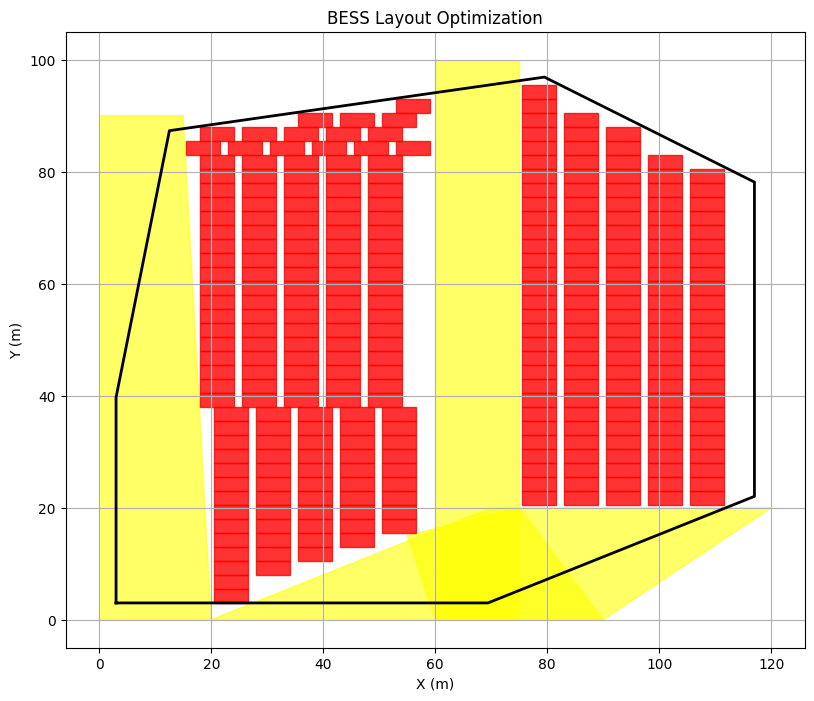

In [32]:
site, non_buildable, mvs, bess = run_optimization(CONFIG)
plot_layout(site, non_buildable, mvs, bess)